Import the standard Python data handling libraries. These libraries first transform the CSV data into dataframes that are easier to work with in standard Python, as well as allowing us to visualize the data in order to understand hidden relationships

Find and download dataset from https://www.kaggle.com/datasets/ashydv/advertising-dataset/data

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Initialize data as a Pandas Dataframe.

In [41]:
df = pd.read_csv('../data/advertising.csv')

Inspecting data

In [42]:
df.head(5)

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [43]:
df.tail(5)

,TV,Radio,Newspaper,Sales
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,14.0
197,177.0,9.3,6.4,14.8
198,283.6,42.0,66.2,25.5
199,232.1,8.6,8.7,18.4


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


We are dealing with 4 columns, the first three columns specify the budget of advertising on the mediums TV, Radio and Newspapers respectively while the target shows the sales of the product. So each row is an instance of a product with the budget in the 3 mediums and corresponding sales achieved. This can therefore be used to be able to formulate the expected sales of a new product based upon the budget allocated to each of these 3 mediums. It can be a very useful metric to be able to identify the best split of budget for a given product based upon historical precedence, as well as being able to forecast the maximum sales based upon budget allocations

All 3 data columns and the target are numerical contentious in nature, therefore simplifying the data handling process

In [45]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


In [46]:
df.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

No Null values

First we split the data we predict on from the data we will predict

In [47]:
X = df.drop(columns=['Sales'])
X

,TV,Radio,Newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4
...,...,...,...
195,38.2,3.7,13.8
196,94.2,4.9,8.1
197,177.0,9.3,6.4
198,283.6,42.0,66.2


In [48]:
target = df['Sales']
target

0      22.1
1      10.4
2      12.0
3      16.5
4      17.9
       ... 
195     7.6
196    14.0
197    14.8
198    25.5
199    18.4
Name: Sales, Length: 200, dtype: float64

Now we visually check the distribution of the 3 numerical columns

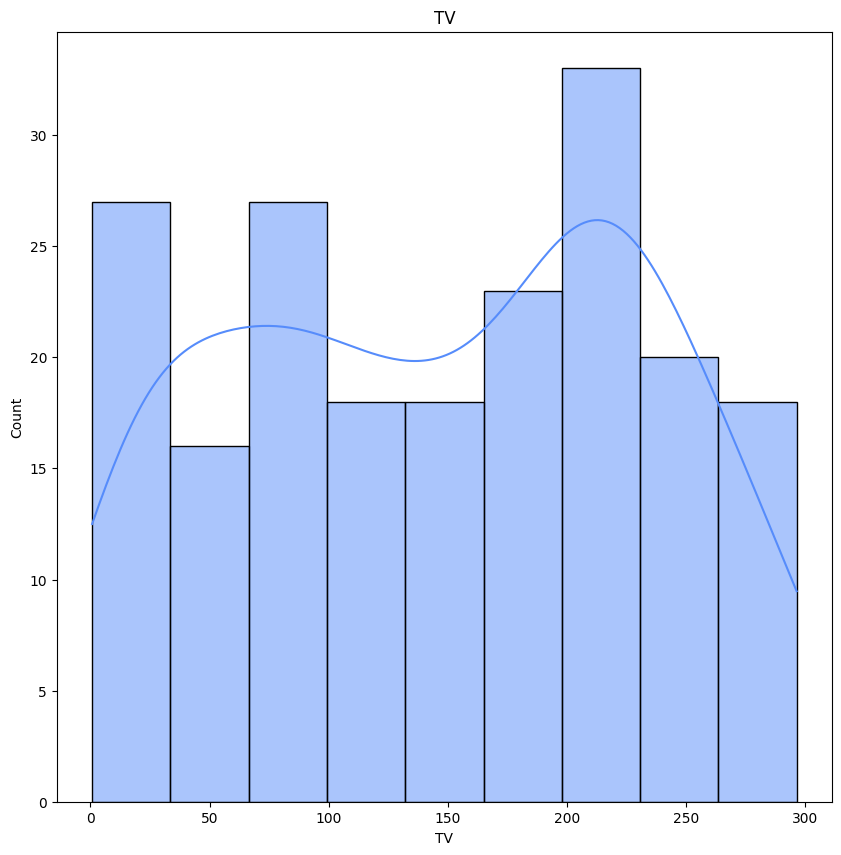

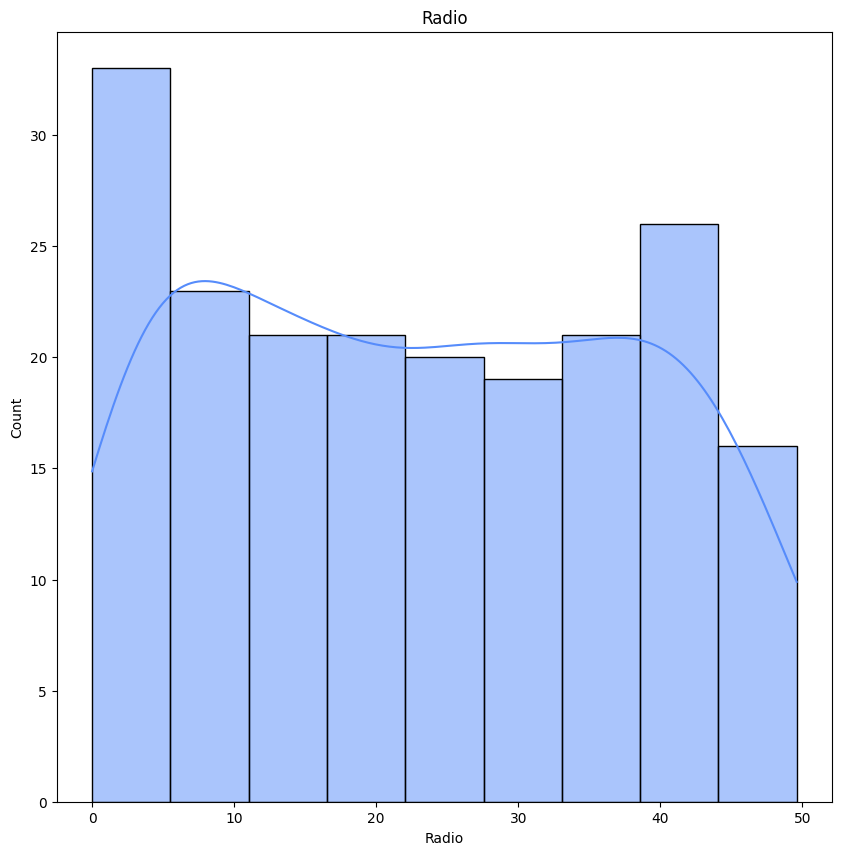

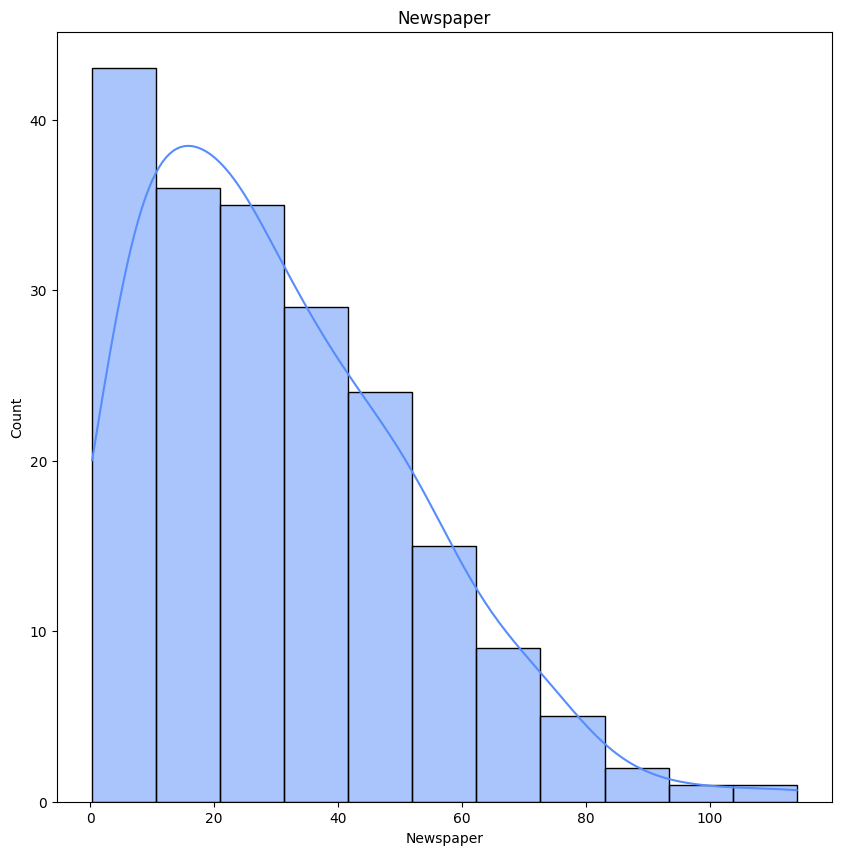

In [49]:
for col in X:
    plt.figure(figsize=(10,10))
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

Can clearly see that while radio and tv have a fairly standard distribution of budget, most newspaper budgets were at the lower end with a few exceptions with large budget allocations

Now we check the relationship of the columns with our target column

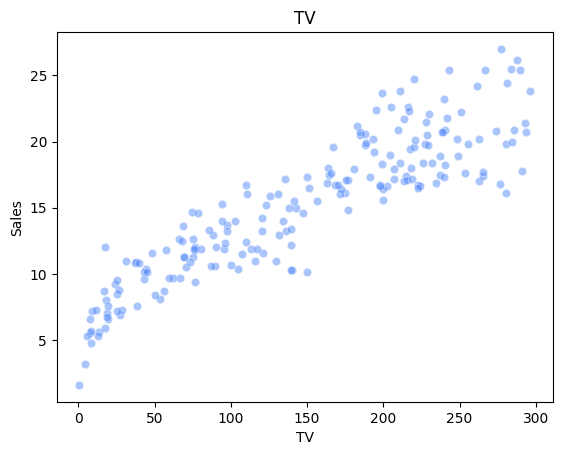

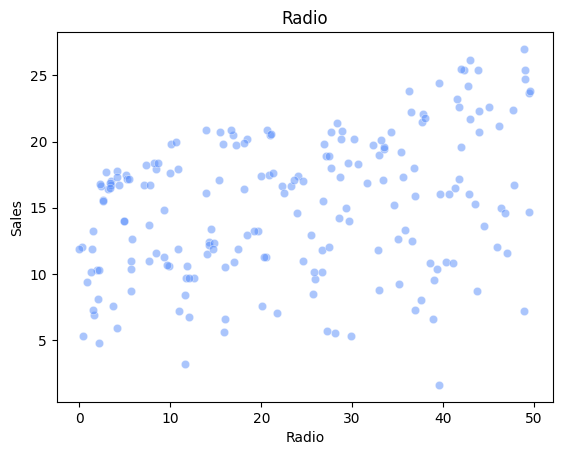

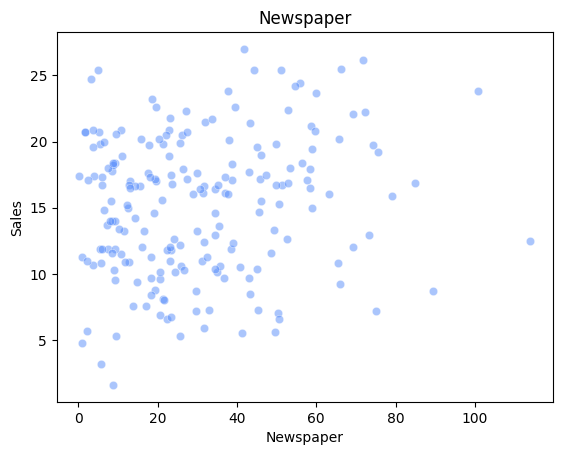

In [50]:
for col in X.columns:
    sns.scatterplot(x=df[col], y=target, alpha=0.5)
    plt.title(col)
    plt.show()

Strong positive correlation between the advertising budget for tv with the sales seen, so in principle, allocating a higher tv budget would result in higher sales. A very small positive correlation can be seen for Radio too but less prominant for newspapers

Split data into test and train

In [51]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, target, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

(160, 3)
(40, 3)


Not removing outliers from IQR as advertising data is not likely to contain erroneous data, may be natural outliers

In [52]:
from sklearn.preprocessing import StandardScaler
scalar = StandardScaler().set_output(transform="pandas")
X_train = scalar.fit_transform(X_train)
X_train
X_test = scalar.transform(X_test)
X_test


,TV,Radio,Newspaper
95,0.157812,0.591127,1.132275
15,0.539253,1.681996,1.132275
30,1.697834,0.367533,0.653801
158,-1.643633,0.950233,0.752455
128,0.835137,1.770079,-1.319286
115,-0.890258,0.821497,1.122409
69,0.793547,1.424524,-0.135434
170,-1.188519,-0.763989,-0.569513
174,0.860091,-1.319587,-0.830947
45,0.298030,-0.025451,0.076673


Create the 3 regression models for the task

In [53]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
linear = LinearRegression()
ridge = Ridge()
lasso = Lasso()

linear.fit(X_train, y_train)
ridge.fit(X_train, y_train)
lasso.fit(X_train, y_train)

,alpha,1.0
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


Evaluate the 3 algorithms on the current task

In [54]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

predLinear = linear.predict(X_test)
predRidge = ridge.predict(X_test)
predLasso = lasso.predict(X_test)

print("MAE: ", mean_absolute_error(y_test, predLinear))
print("RMSE:", root_mean_squared_error(y_test, predLinear))
print("R²:  ", r2_score(y_test, predLinear))

MAE:  1.2748262109549349
RMSE: 1.7052146229349232
R²:   0.9059011844150826


In [55]:
print("MAE: ", mean_absolute_error(y_test, predRidge))
print("RMSE:", root_mean_squared_error(y_test, predRidge))
print("R²:  ", r2_score(y_test, predRidge))

MAE:  1.2734471720192524
RMSE: 1.7074302367919387
R²:   0.9056564972278859


In [56]:
print("MAE: ", mean_absolute_error(y_test, predLasso))
print("RMSE:", root_mean_squared_error(y_test, predLasso))
print("R²:  ", r2_score(y_test, predLasso))

MAE:  1.7891448881743948
RMSE: 2.343866119206355
R²:   0.8222164135010256
